## GRAPH 05

모든 정점 사이에 간선이 존재하는 그래프(완전 그래프)에서는 인접 행렬을 사용한다.

- 완전 그래프에서 간선 수는 V(V-1)/2 (무방향) 또는 V(V-1) (방향)으로, 밀도가 최대이다.
- 인접 리스트는 각 정점마다 연결 리스트를 관리하는 포인터 오버헤드가 발생하며, 이미 모든 쌍이 연결된 경우 그 이점(공간 절약)이 없다.
- 인접 행렬은 두 정점 간 간선 존재 여부를 O(1)에 확인할 수 있다.

## GRAPH 06

정점 간 간선이 아주 드문 희소 그래프(Sparse Graph)에서는 인접 리스트를 사용한다.

- 인접 행렬은 V×V 크기의 공간을 항상 사용하므로, 간선이 적을 경우 대부분의 칸이 0(또는 null)이 되어 공간 낭비가 심하다.
- 인접 리스트는 실제 존재하는 간선만 저장하므로 공간 복잡도가 O(V + E)이며, E가 작을 때 훨씬 효율적이다.
- DFS, BFS 등의 탐색 시 인접 리스트는 실제 연결된 정점만 순회하므로 시간 복잡도도 유리하다.

## GRAPH 08

DFS(1) 수행 시 v=1인 상태에서 인접한 노드 순회:
1의 인접 정점: 2, 4

- x=2: visited=no → (1) DFS(2) 호출
- x=4: 이 시점에 4가 visited인지 확인 필요

DFS(2) 안으로 들어가면 v=2가 되므로 모함수가 DFS(1)이 아니므로 카운트를 하지 않는다.


DFS(2)가 끝나고 돌아와서 x=4 확인:

DFS(2)→DFS(3), DFS(5)→DFS(6)→DFS(4) 순으로 4가 방문됨
DFS(1)로 돌아왔을 때 x=4: visited=YES → 호출 안 함

따라서 DFS(x)가 호출되는 시점의 모함수 (DFS(v))에서 v=1인 경우만 셀 경우,
**1번**이다.

(답) 1번

##GRAPH 12
- 아래 그래프를 기준으로 풀이한다 (정점 레이블은 위치 기준으로 A~H로 정의)
- 문제 그래프의 "안" 표기 정점을 H로 지정

그래프 간선 및 가중치:
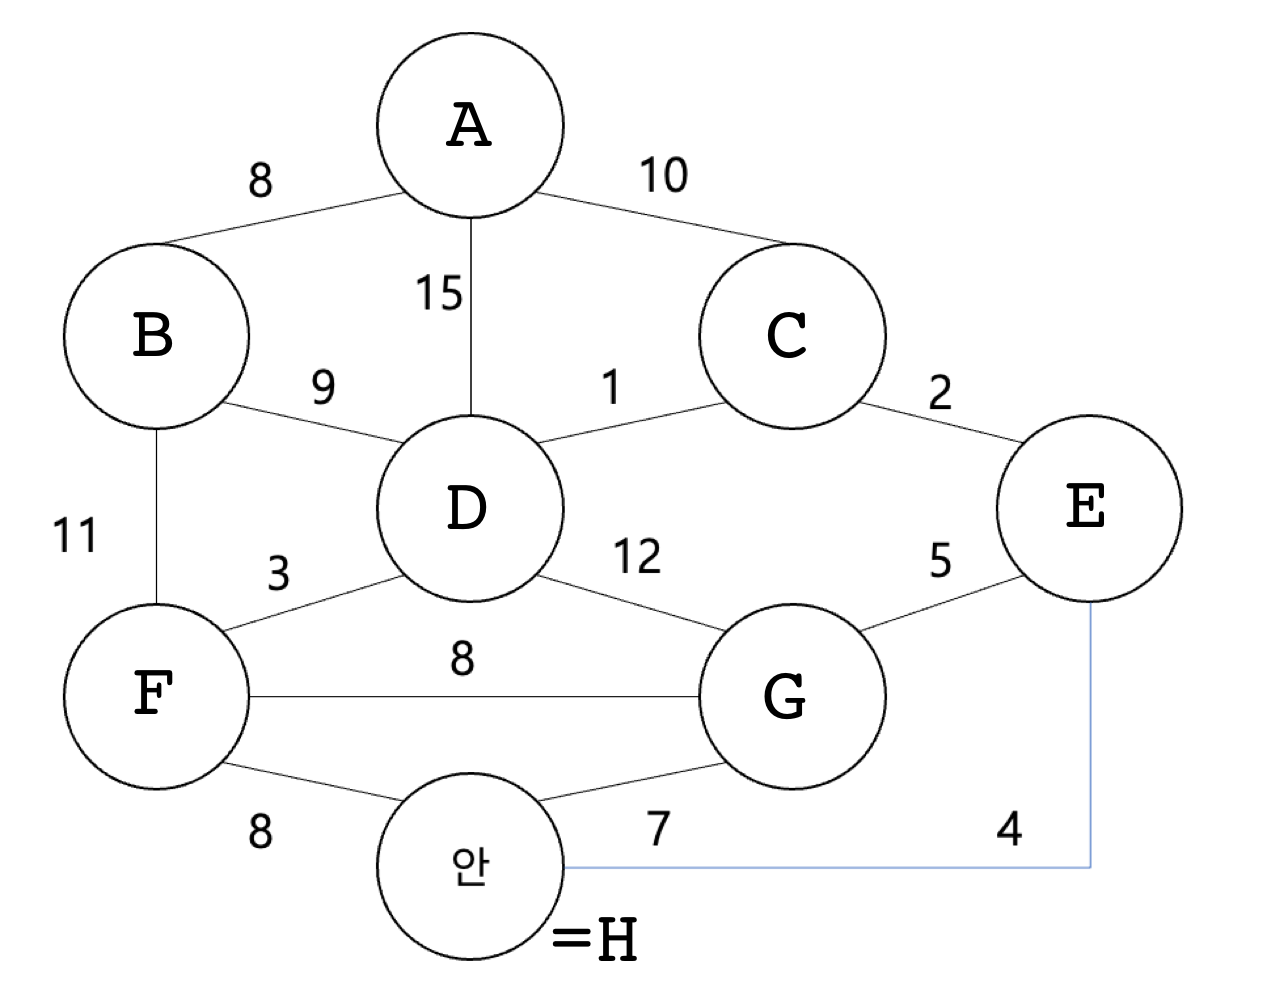

**(1) 프림 알고리즘**
- 간선이 추가될 떄마다 그래프를 새로 그려 과정을 보였다.
- 시작 정점은 "안(H)"로 한다.
- 임의의 시작 정점에서 출발해, 현재 트리에 연결된 간선 중 가중치가 가장 작은 것을 하나씩 추가한다. 정점 중심으로 확장하며, 우선순위 큐로 구현한다.
- 과정은 다음과 같다:
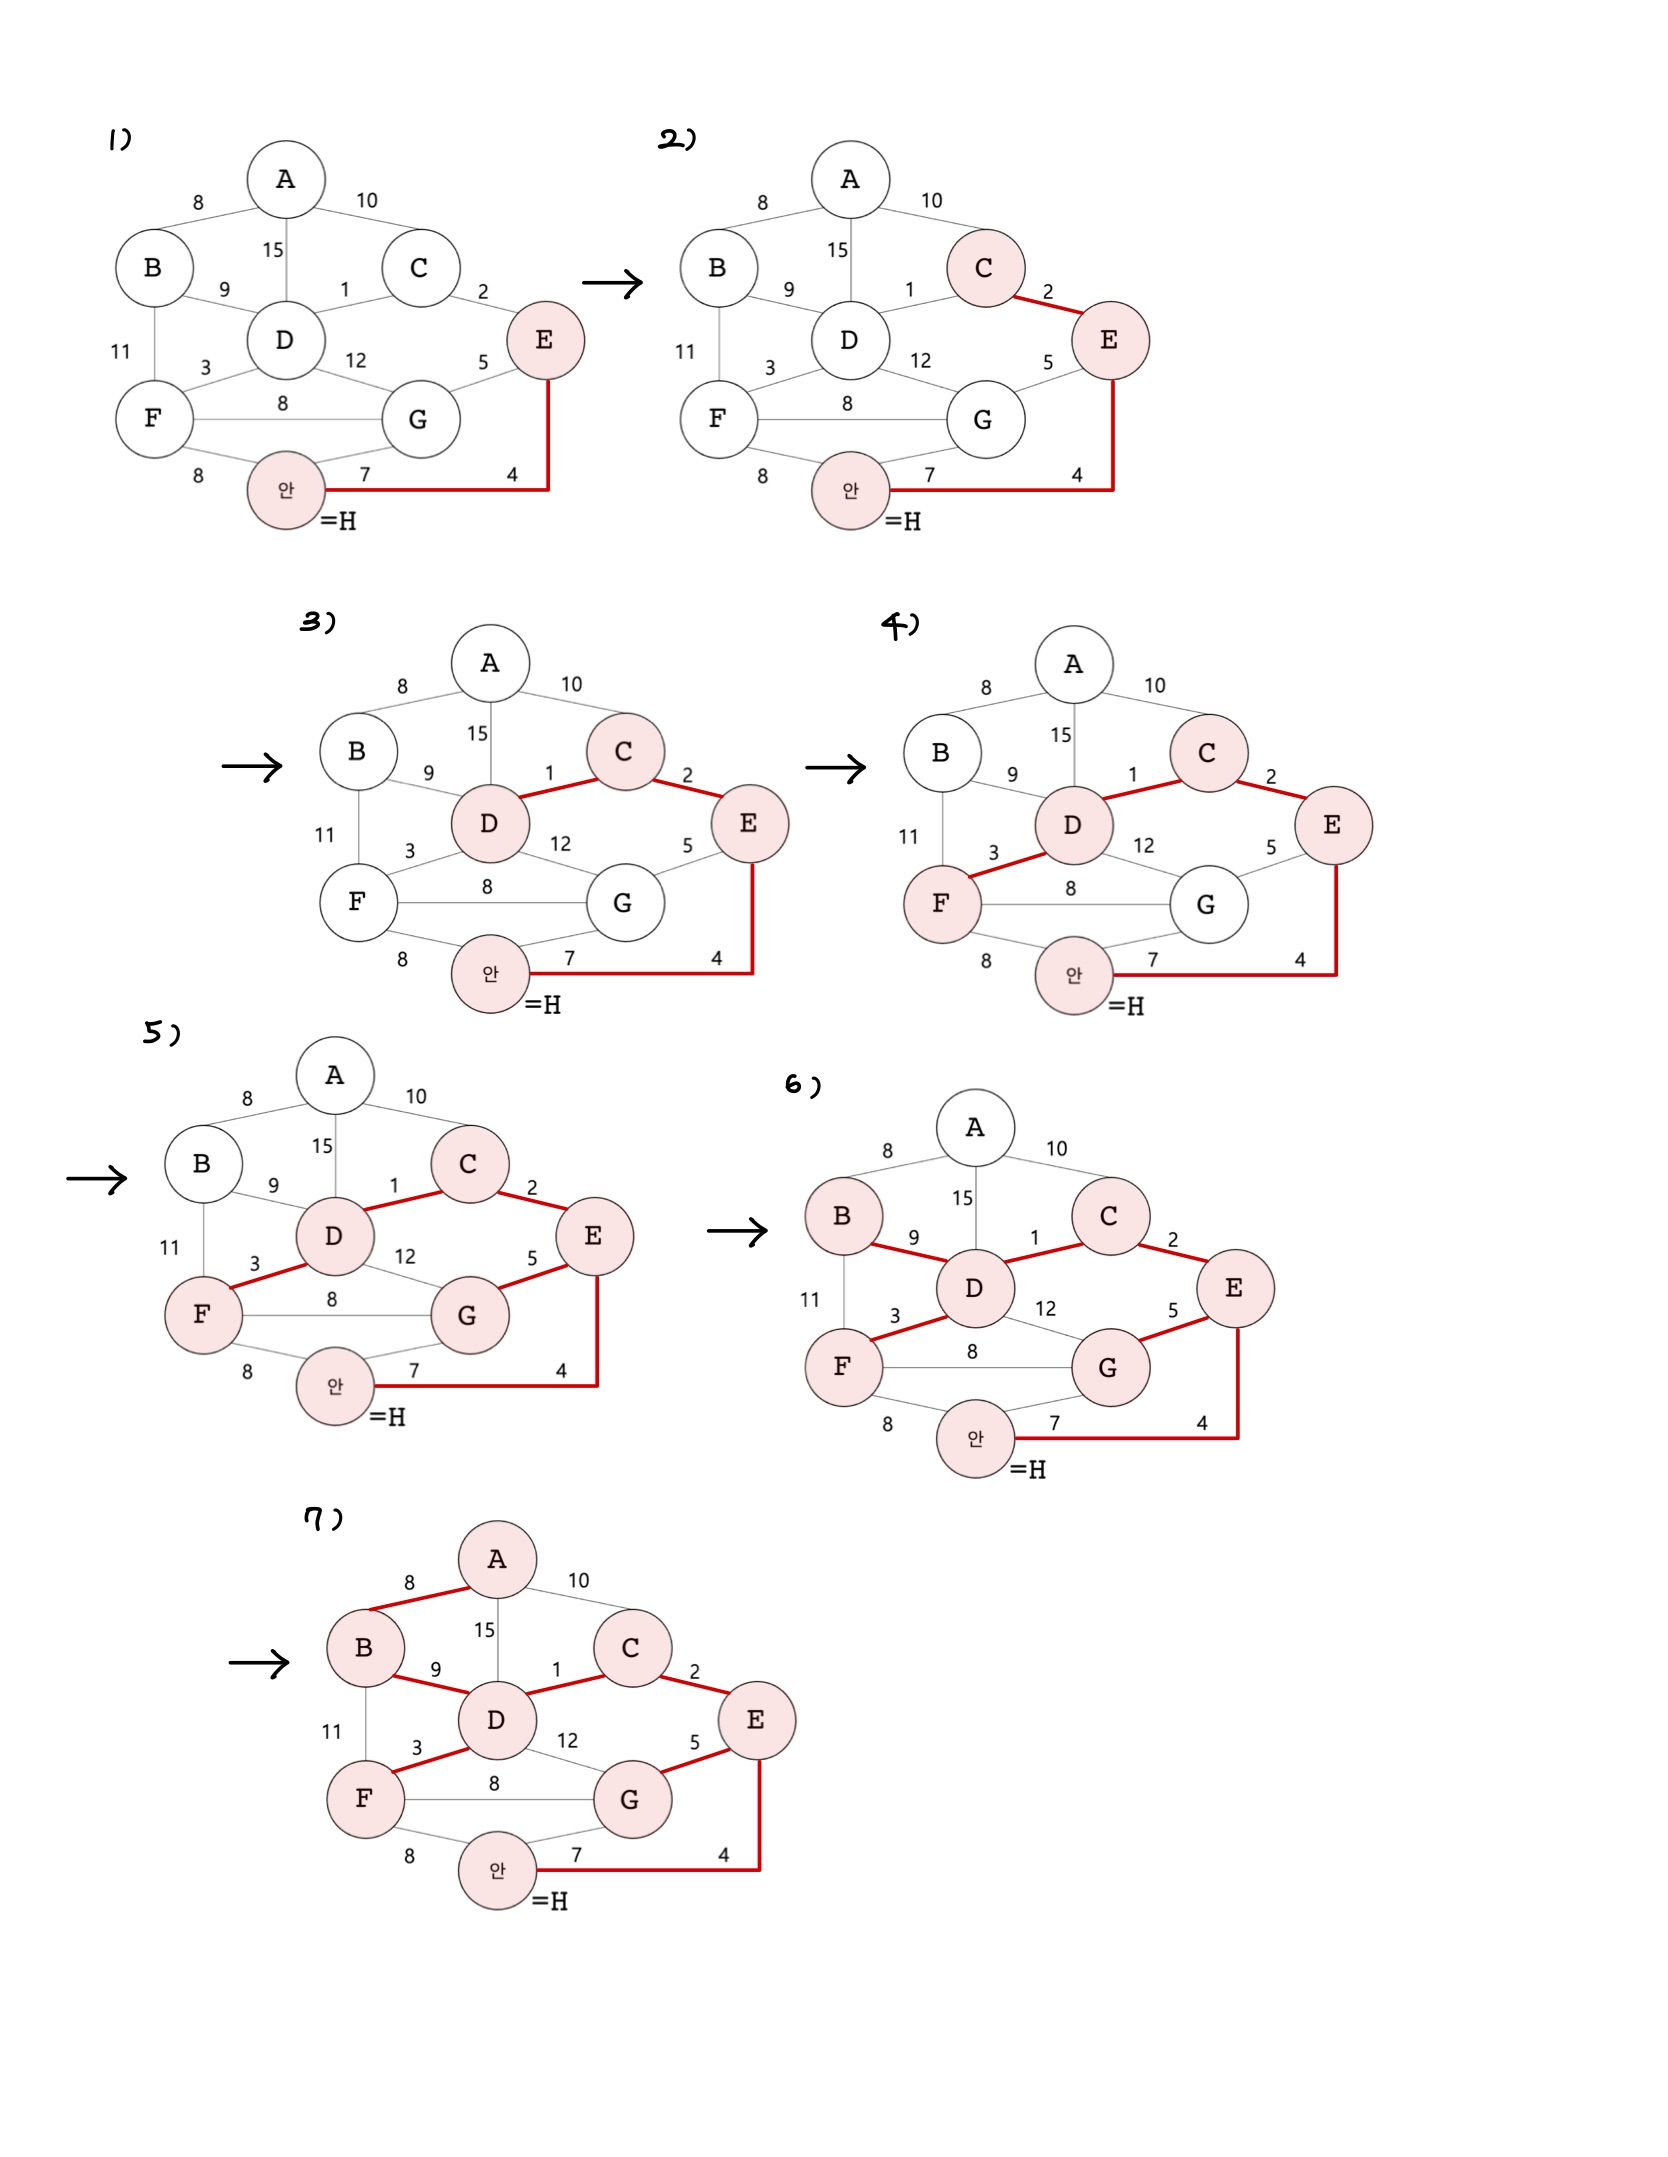

**(2) 크루스칼 알고리즘**
- 모든 간선을 가중치 오름차순으로 정렬한 뒤, 사이클을 만들지 않는 간선을 순서대로 추가한다.

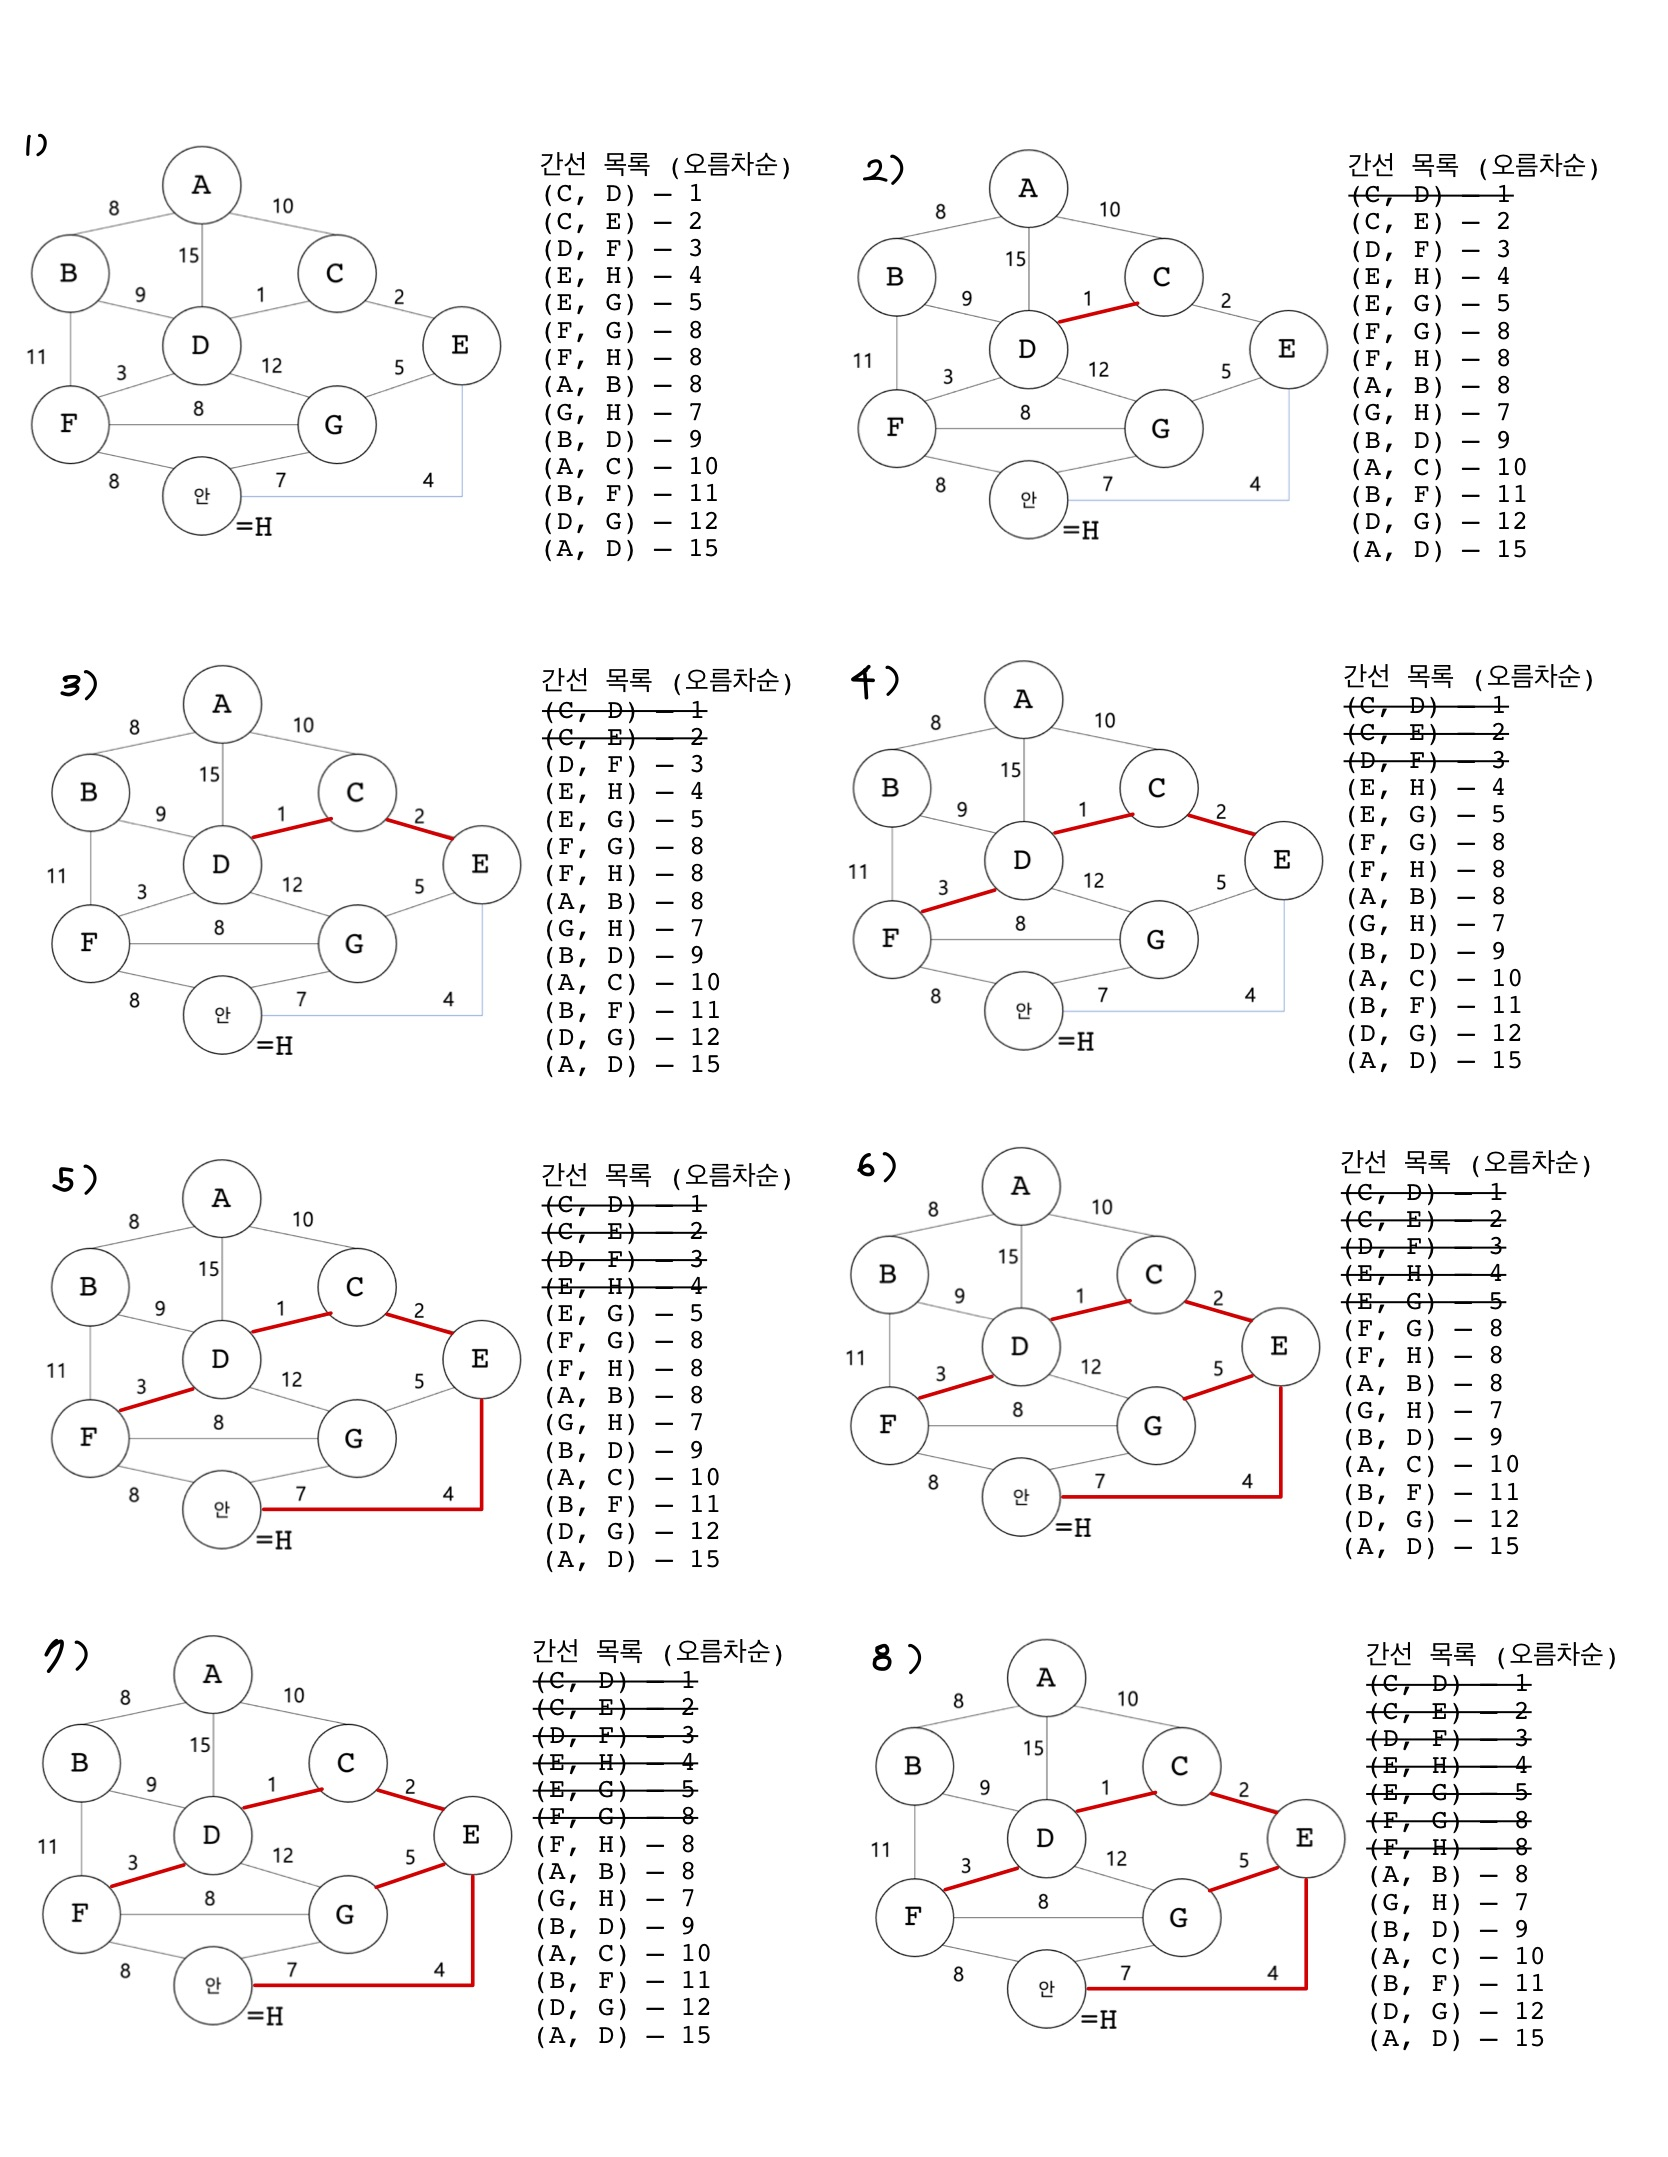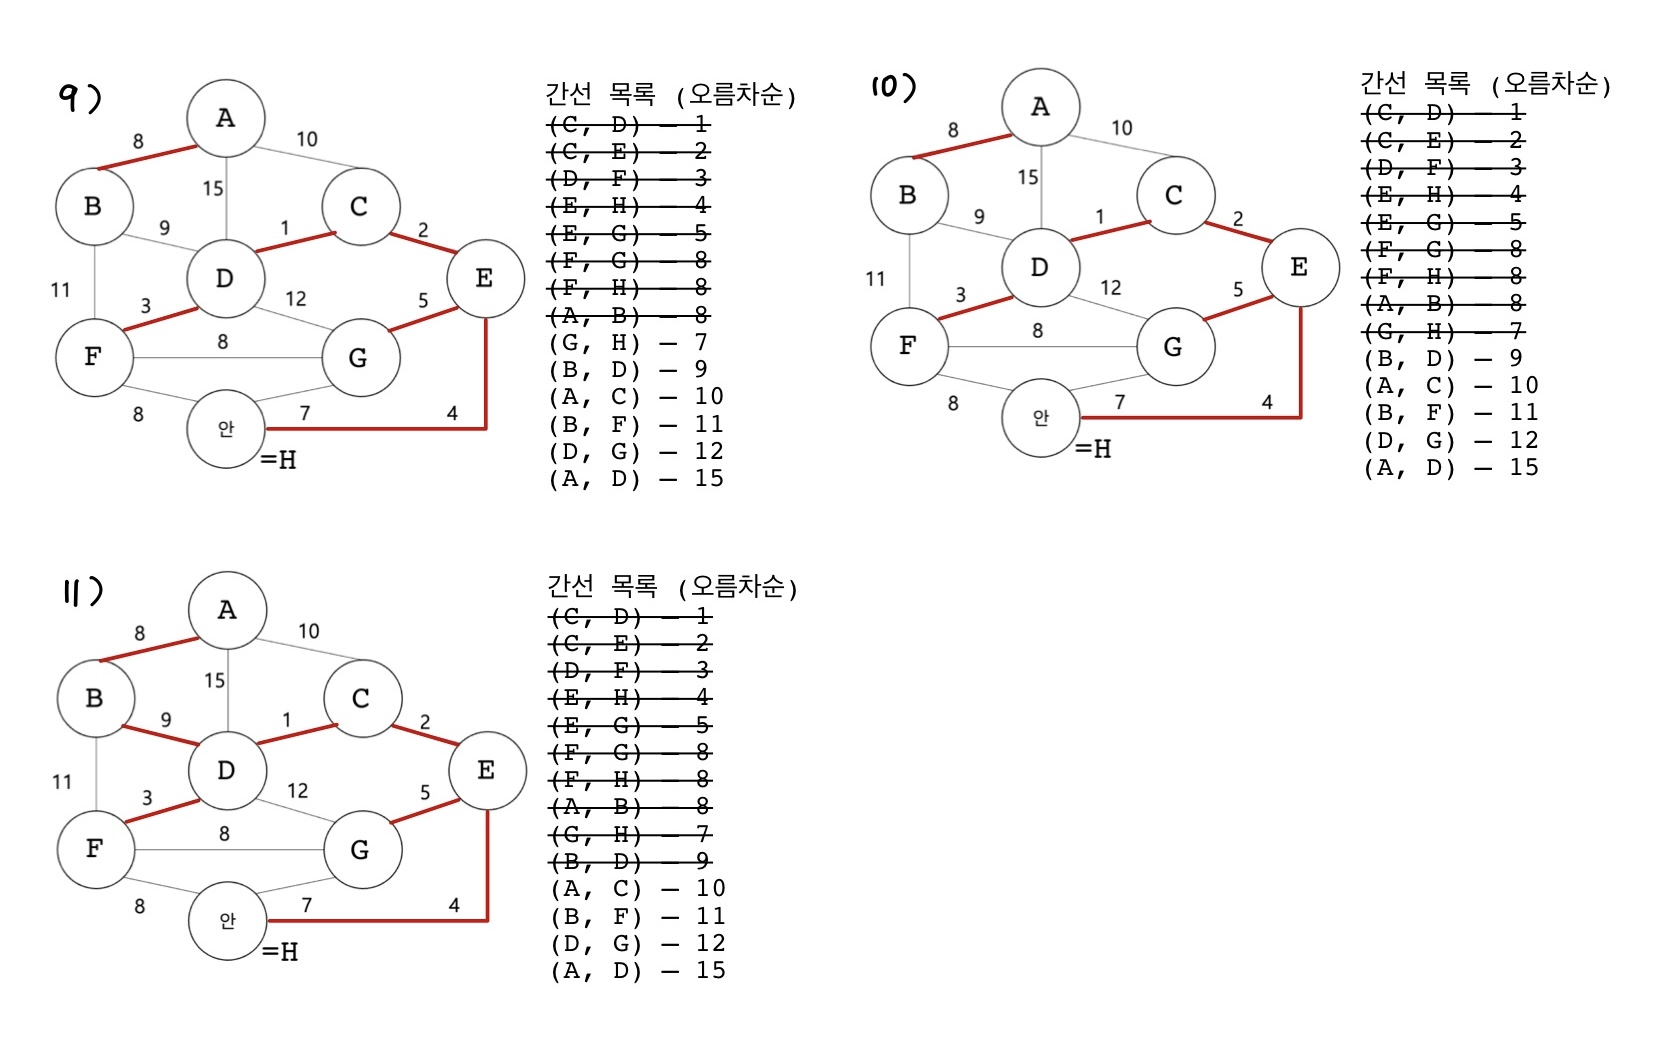

## GRAPH 16

### *STACK을 사용한 위상 정렬 수도 코드

```
Topological Sort with STACK:
    Create STACK
    Create visited <- false
    for each vertex v
        if(!visited[v])
            DFS(v, visited, STACK)
    while(!STACK.empty)
        STACK.pop

DFS(v, visited, STACK)
    visited[v] <- true
    for i in Adj[v]
        if(!visited[i])
            DFS
    STACK.push(v)
```

### *가능한 위상 정렬 순서 수

그래프 간선: a→b, a→d, b→c, d→e, d→f, e→f, e→g, f→g, f→h

진입차수(in-degree) 분석:
- a: 0, b: 1(a), c: 1(b), d: 1(a), e: 1(d), f: 2(d,e), g: 2(e,f), h: 1(f)

시작은 반드시 **a** (유일한 진입차수 0).


이 관계를 바탕으로 각 정점의 선행 관계(의존성)를 묶어서 시각화하면 다음과 같은 구조를 가진다.

- $a$는 가장 앞서 있으며, $b$와 $d$로 갈라진다.
- $b$ 경로: $a \rightarrow b \rightarrow c$ ($c$는 여기서 끝남)
- $d$ 경로: $a \rightarrow d \rightarrow e \rightarrow f \rightarrow \{g, h\}$
  - $d$ 이후의 순서는 고정된다: $d \rightarrow e \rightarrow f$ (간선 $d \rightarrow e$, $d \rightarrow f$, $e \rightarrow f$에 의해)
  - $f$ 이후에는 $g$와 $h$로 갈라진다. ($f \rightarrow g$, $f \rightarrow h$)

---

#### 1. 부분 독립 구조 나누기

전체 그래프는 $a$로 시작해야 한다. $a$를 방문한 이후의 구조는 크게 두 갈래로 나뉜다.

- **Group 1** ($b, c$ 그룹): 순서가 $b \rightarrow c$로 고정됨. (원소 2개)
- **Group 2** ($d, e, f, g, h$ 그룹): $d \rightarrow e \rightarrow f$ 순서가 고정되고, 그 뒤에 $g$와 $h$가 오는 구조. (원소 5개)

###### Group 2 안에서 가능한 순서 계산

- $d \rightarrow e \rightarrow f$는 순서가 고정이다.
- $f$ 다음에 $g$와 $h$를 방문해야 하는데, $g$와 $h$ 사이에는 간선이 없다.
- 즉, $f$ 뒤에 나오는 순서는 $[g, h]$ 또는 $[h, g]$ **2가지**가 가능하다.
- 따라서 Group 2 자체로 만들 수 있는 위상 정렬의 경우의 수는 **2가지**이다.
  - $d \rightarrow e \rightarrow f \rightarrow g \rightarrow h$
  - $d \rightarrow e \rightarrow f \rightarrow h \rightarrow g$

---

#### 2. 두 그룹의 결합 (조합 계산)

$a$를 맨 앞에 고정해 둔 상태에서, 나머지 자리(총 7자리)에 Group 1(2개)과 Group 2(5개)의 원소들을 섞어 넣는 경우의 수를 구한다. 단, 각 그룹 내부의 상대적인 순서는 유지되어야 한다.

**자리를 고르는 경우의 수:**

총 7개의 빈자리 중에서 Group 1 ($b, c$)이 들어갈 2개의 자리를 고르는 조합의 수와 같다.

$$\binom{7}{2} = \frac{7 \times 6}{2 \times 1} = 21$$

**각 경우별 Group 2의 내부 변형 수:**

위에서 구한 21가지의 배치마다, Group 2가 가질 수 있는 자체 경우의 수 2가지 ($g$, $h$의 순서 교환)가 곱해진다.
(Group 1은 $b \rightarrow c$ 고정이므로 경우의 수 1가지)

---

#### 3. 최종 계산

$$\text{가능한 위상 정렬의 수} = \binom{7}{2} \times (\text{Group 1의 경우의 수}) \times (\text{Group 2의 경우의 수})$$

$$= 21 \times 1 \times 2 = \text{42}$$

따라서 이 그래프에서 가능한 위상 정렬 순서의 총 개수는 **42가지**이다.

## GRAPH 17

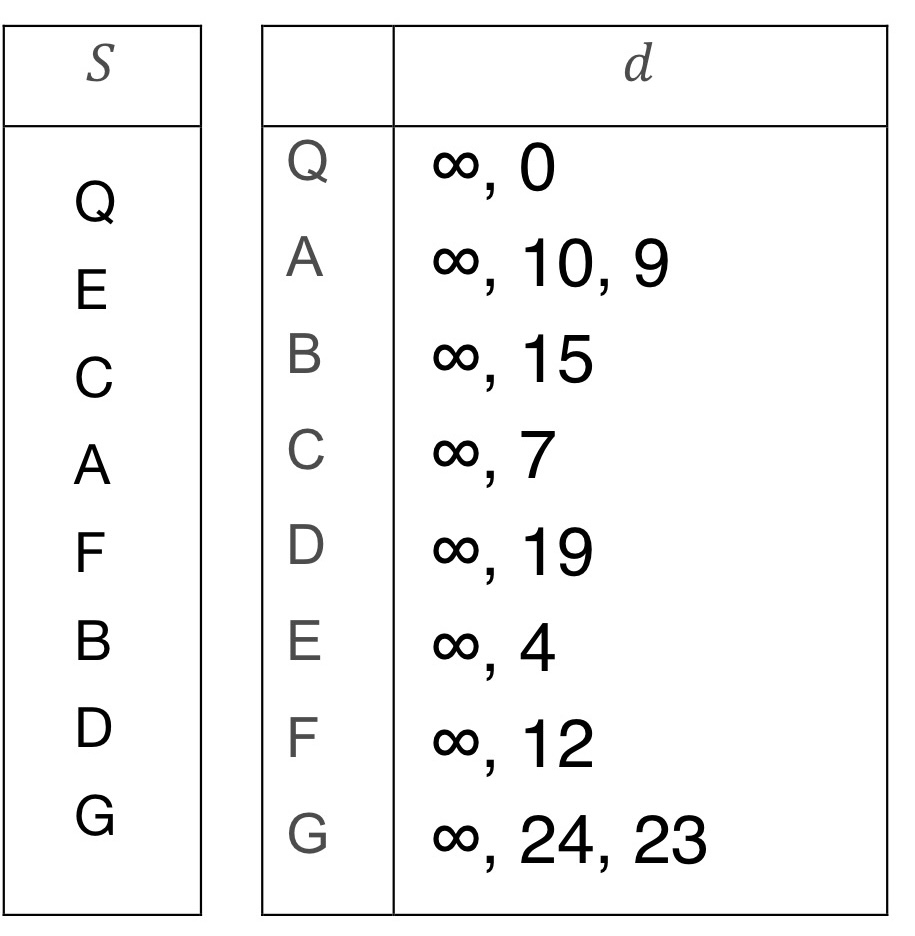

- 풀이: 다익스트라 알고리즘은 시작 정점에서 다른 모든 정점까지의 최단 거리를 구하는 알고리즘이다. 단, 간선의 가중치가 음수이면 사용할 수 없다.

  - 동작 원리
초기에는 시작 정점의 거리를 0, 나머지는 모두 ∞로 설정한다. 이후 아래 과정을 반복한다.

1. 아직 확정되지 않은 정점 중 거리가 가장 작은 정점 u를 선택한다.
2. u를 통해 인접 정점 v에 가는 경로가 기존보다 짧으면 v의 거리를 갱신한다 (relaxation).
3. 모든 정점이 확정될 때까지 반복한다.

## GRAPH 18

**다익스트라 알고리즘이 음의 가중치에서 실패하는 예 (정점 3개):**

```
정점: s, u, v
간선:
  s → u : 2
  s → v : 5
  u → v : -4
```

다익스트라 수행:
1. s 선택 (d=0): d[u]=2, d[v]=5
2. u 선택 (d=2): d[v] = min(5, 2+(-4)) = **1** → 갱신 시도

그러나 다익스트라는 u를 S에 추가한 후 v의 이전 거리(5)를 기준으로 v를 처리하면,  
v가 S에 들어가기 전에 u를 통한 경로(거리 1)가 반영되지 않을 수 있음.

→ **문제:** s→v 직접 경로(5)가 s→u→v 경로(2-4=-2)보다 크므로 최단 거리는 -2이어야 하나,  
다익스트라는 greedy 특성상 한번 S에 추가된 정점의 거리를 재갱신하지 않기 때문에 **잘못된 결과**가 나올 수 있다.

## GRAPH 22

**벨만-포드 알고리즘에서 답을 구할 수 없는 경우:**

그래프에 **음의 사이클**이 존재할 때 답을 구할 수 없다.

- 벨만-포드는 V-1번의 릴랙세이션(relaxation) 반복 후 한 번 더 확인하여, 거리가 여전히 갱신되는 간선이 존재하면 음의 사이클이 있다고 판단한다.
- 음의 사이클이 있으면 해당 사이클을 돌 때마다 경로 비용이 계속 감소하므로 최단 거리가 -∞로 발산하여 정의되지 않는다.

## SORTING 05

초기 배열: `12 70 30 20 55 25`

### (1) 선택 정렬 (Selection Sort)

미정렬 구간에서 최대 원소를 찾아 맨 뒤와 교환한다.

| 단계 | 배열 상태 | 비고 |
|------|-----------|------|
| 초기 | 12 70 30 20 55 25 | |
| 1 | 12 25 30 20 55 \| **70** | max=70(idx 1), 70↔25 교환 |
| 2 | 12 25 30 20 \| **55** 70 | max=55(idx 4), 교환 없음 |
| 3 | 12 25 20 \| **30** 55 70 | max=30(idx 2), 30↔20 교환 |
| 4 | 12 20 \| **25** 30 55 70 | max=25(idx 1), 25↔20 교환 |
| 5 | 12 \| **20** 25 30 55 70 | max=20(idx 1), 교환 없음 |
| 완료 | **12 20 25 30 55 70** | |

**결과:** `12 20 25 30 55 70`

### (2) 버블 정렬 (Bubble Sort)

인접한 두 원소를 비교하여 큰 값을 뒤로 보낸다.

**Pass 1:** (큰 값이 맨 뒤로)
```
12 70 30 20 55 25
12 30 70 20 55 25   (70>30, 교환)
12 30 20 70 55 25   (70>20, 교환)
12 30 20 55 70 25   (70>55, 교환)
12 30 20 55 25 [70] (70>25, 교환) → 70 고정
```

**Pass 2:**
```
12 30 20 55 25
12 20 30 55 25   (30>20, 교환)
12 20 30 55 25   (30<55, 유지)
12 20 30 25 [55] (55>25, 교환) → 55 고정
```

**Pass 3:**
```
12 20 30 25
12 20 25 [30]    (30>25, 교환) → 30 고정
```

**Pass 4:**
```
12 20 25  → 교환 없음 → 25 고정
```

**Pass 5:**
```
12 20 → 교환 없음 → 정렬 완료
```

| Pass | 배열 상태                  |
|------|---------------------------|
| 초기 | 12 70 30 20 55 25         |
| 1    | 12 30 20 55 25 **70**     |
| 2    | 12 20 30 25 **55** 70     |
| 3    | 12 20 25 **30** 55 70     |
| 4    | 12 20 **25** 30 55 70     |
| 5    | **12 20** 25 30 55 70     |

**결과:** `12 20 25 30 55 70`

### (3) 삽입 정렬 (Insertion Sort)

정렬된 앞 부분에 현재 원소를 올바른 위치에 삽입한다.

| 단계 | key  | 배열 상태                       |
|------|------|---------------------------------|
| 초기 | -    | [12] 70 30 20 55 25             |
| 1    | 70   | [12 **70**] 30 20 55 25         |
| 2    | 30   | [12 **30** 70] 20 55 25         |
| 3    | 20   | [12 **20** 30 70] 55 25         |
| 4    | 55   | [12 20 30 **55** 70] 25         |
| 5    | 25   | [12 20 **25** 30 55 70]         |

**결과:** `12 20 25 30 55 70`

## SORTING 06

초기 배열: `12 70 30 20 55 25 40 50`

### (1) 병합 정렬 (Merge Sort)

**분할 과정:**
```
[12 70 30 20 55 25 40 50]
[12 70 30 20]      [55 25 40 50]
[12 70] [30 20]    [55 25] [40 50]
[12][70] [30][20]  [55][25] [40][50]
```

**병합 과정:**
```
[12][70] → [12 70]
[30][20] → [20 30]
[12 70] + [20 30] → [12 20 30 70]

[55][25] → [25 55]
[40][50] → [40 50]
[25 55] + [40 50] → [25 40 50 55]

[12 20 30 70] + [25 40 50 55] → [12 20 25 30 40 50 55 70]
```

**결과:** `12 20 25 30 40 50 55 70`

### (2) 힙 정렬 (Heap Sort)
- 풀이: 힙정렬은 배열을 최대 힙으로 만든 뒤, 루트(최댓값)를 배열 끝으로 보내고 힙 크기를 줄이는 과정을 반복한다. 핵심 규칙은 부모 ≥ 자식을 유지하는 것이며, 이 규칙이 깨지면 MAX-HEAPIFY로 아래로 내려보내 고친다. 정렬은 ① Build Max Heap → ② 루트↔끝 교환 → ③ HEAPIFY 순서를 n-1번 반복하면 완성된다.

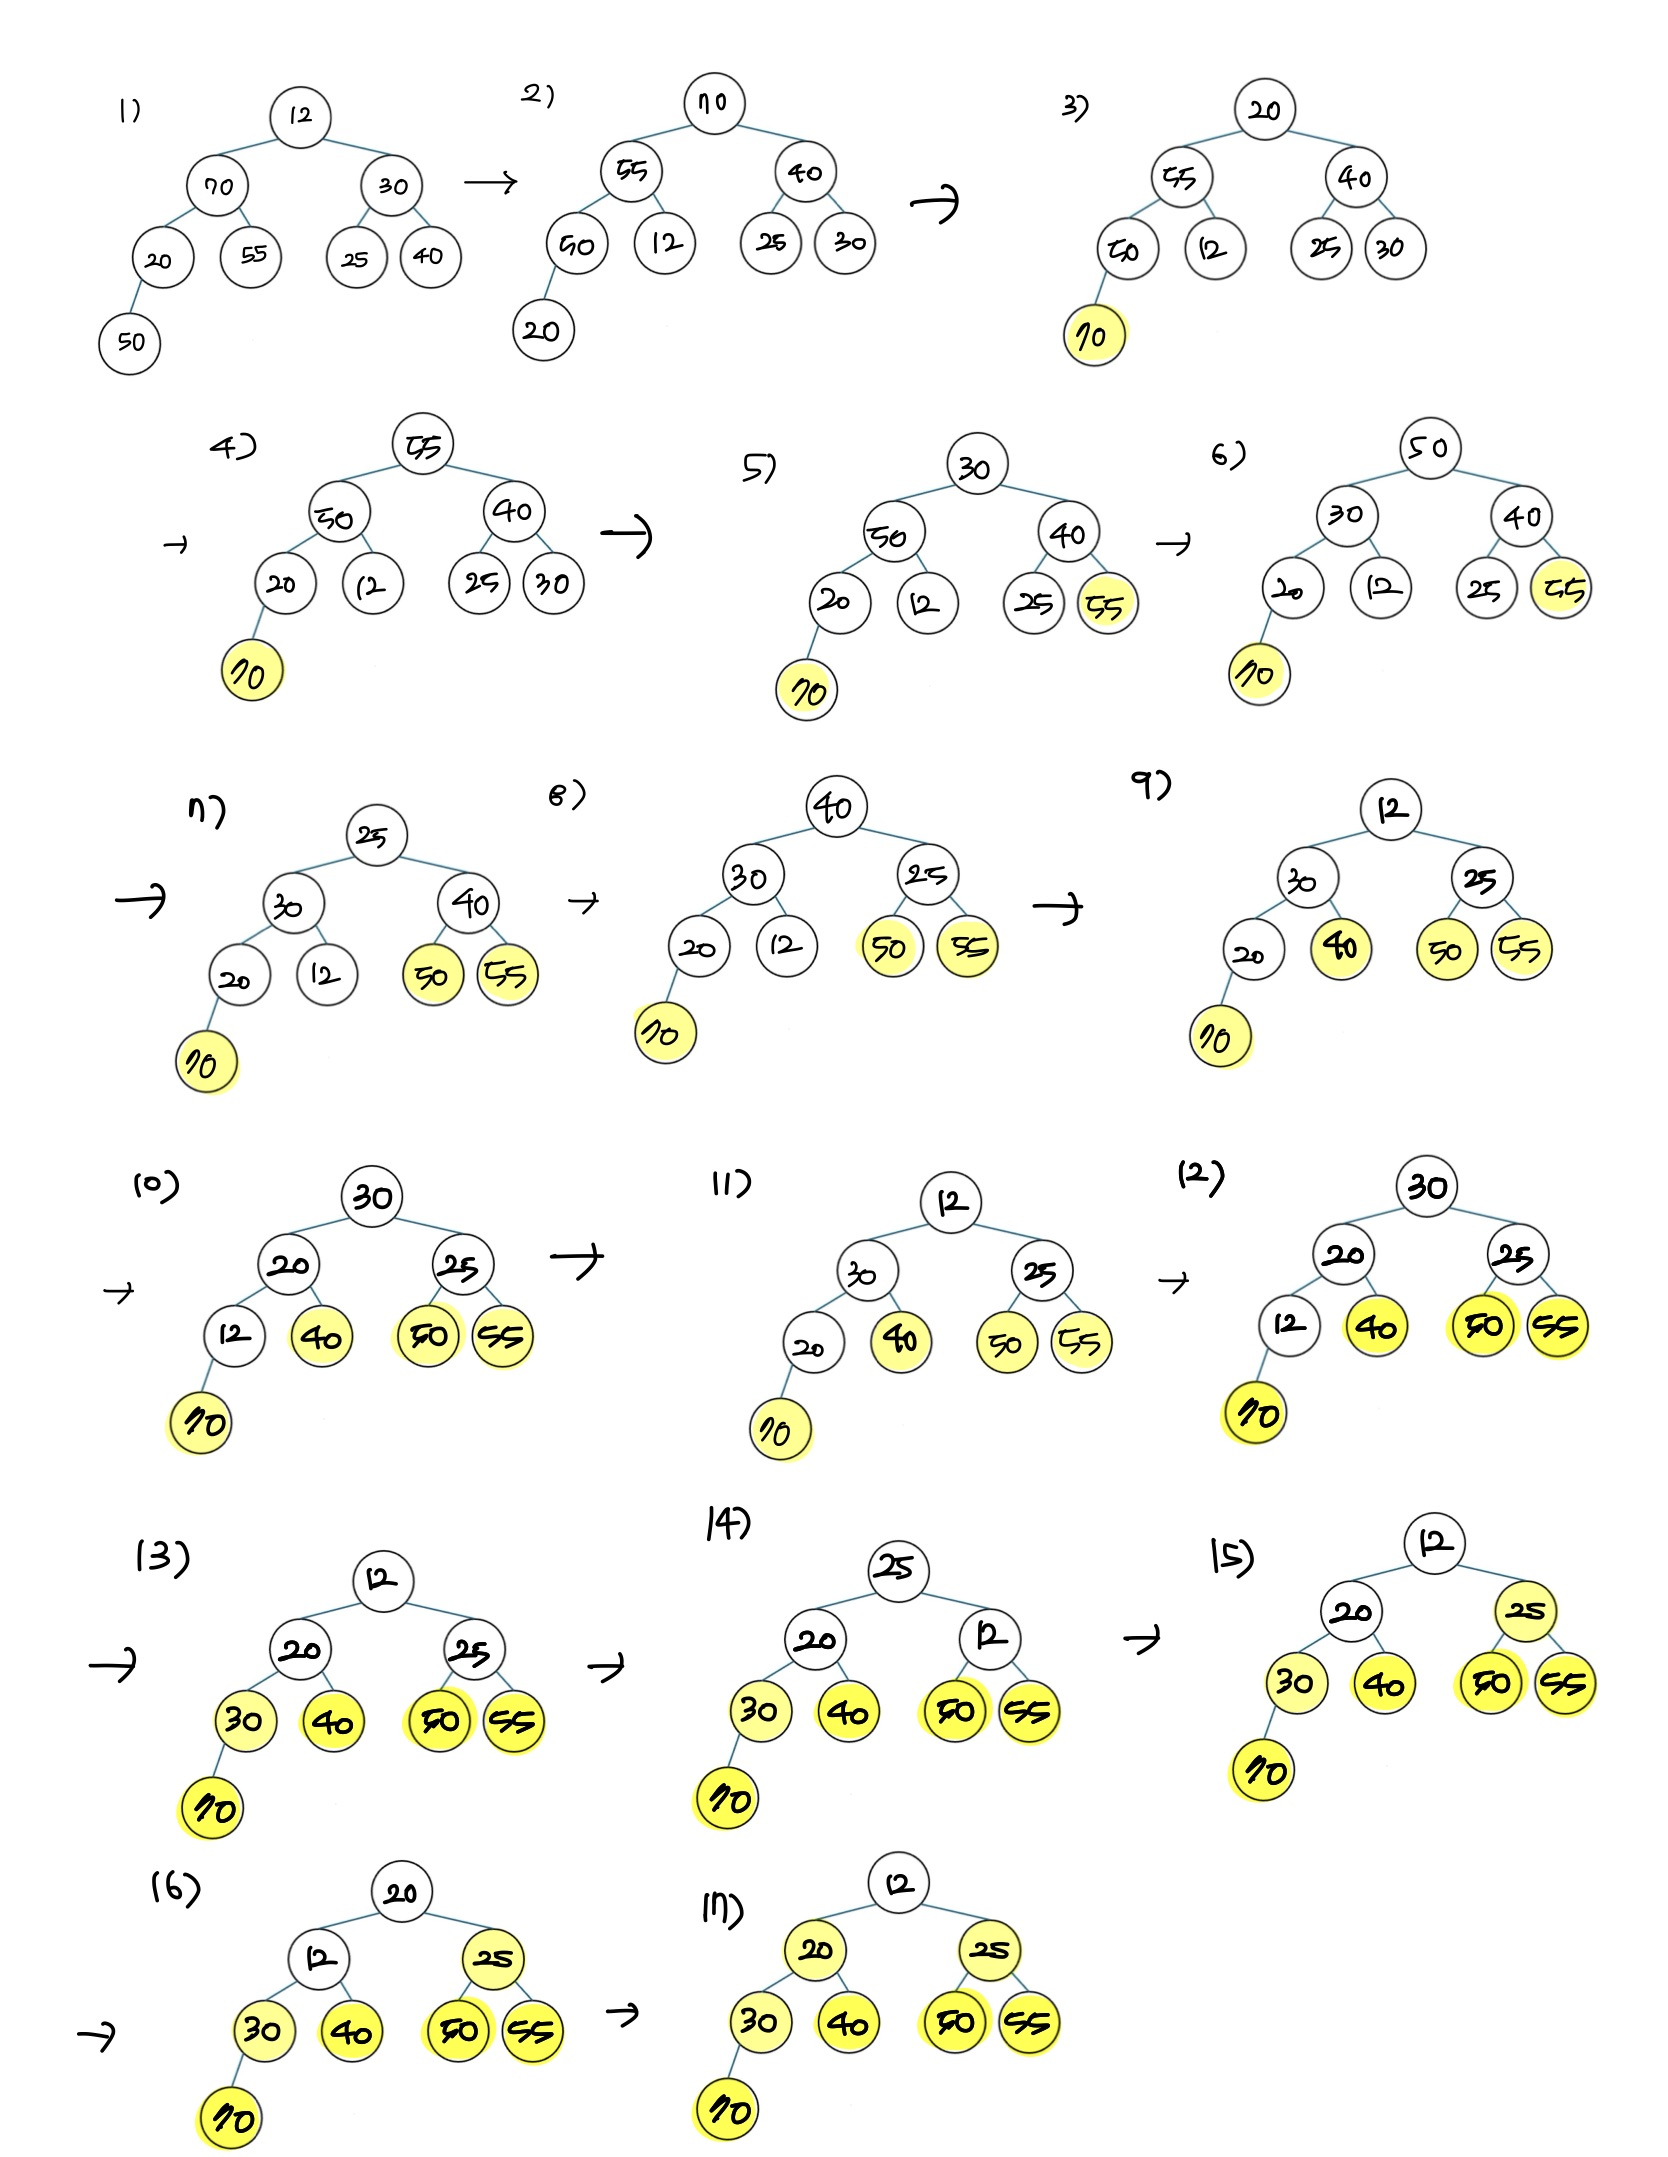

### (3) 퀵 정렬 (Quick Sort)

pivot = 마지막 원소 기준

**초기:** `12 70 30 20 55 25 40 50`  pivot = **50**

```
partition: [12 70 30 20 55 25 40 | 50]
  → 50보다 작은 것: 12, 30, 20, 25, 40
  → 50보다 큰 것: 70, 55
결과: [12 30 20 25 40] 50 [70 55]
```

**왼쪽 [12 30 20 25 40]** pivot = **40**
```
partition: [12 30 20 25 | 40]
  → 40보다 작은 것: 12, 30, 20, 25
결과: [12 30 20 25] 40 []
```

**[12 30 20 25]** pivot = **25**
```
  → 25보다 작은 것: 12, 20
  → 25보다 큰 것: 30
결과: [12 20] 25 [30]
```

**[12 20]** pivot = **20**
```
결과: [12] 20 []
```

→ 왼쪽 결과: `12 20 25 30 40`

**오른쪽 [70 55]** pivot = **55**
```
결과: [] 55 [70]
```

→ 오른쪽 결과: `55 70`

**전체 병합:**
```
[12 20 25 30 40] + 50 + [55 70]
```

**결과:** `12 20 25 30 40 50 55 70`